# <center><strong>Water potability Classification</strong></center>
----------------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

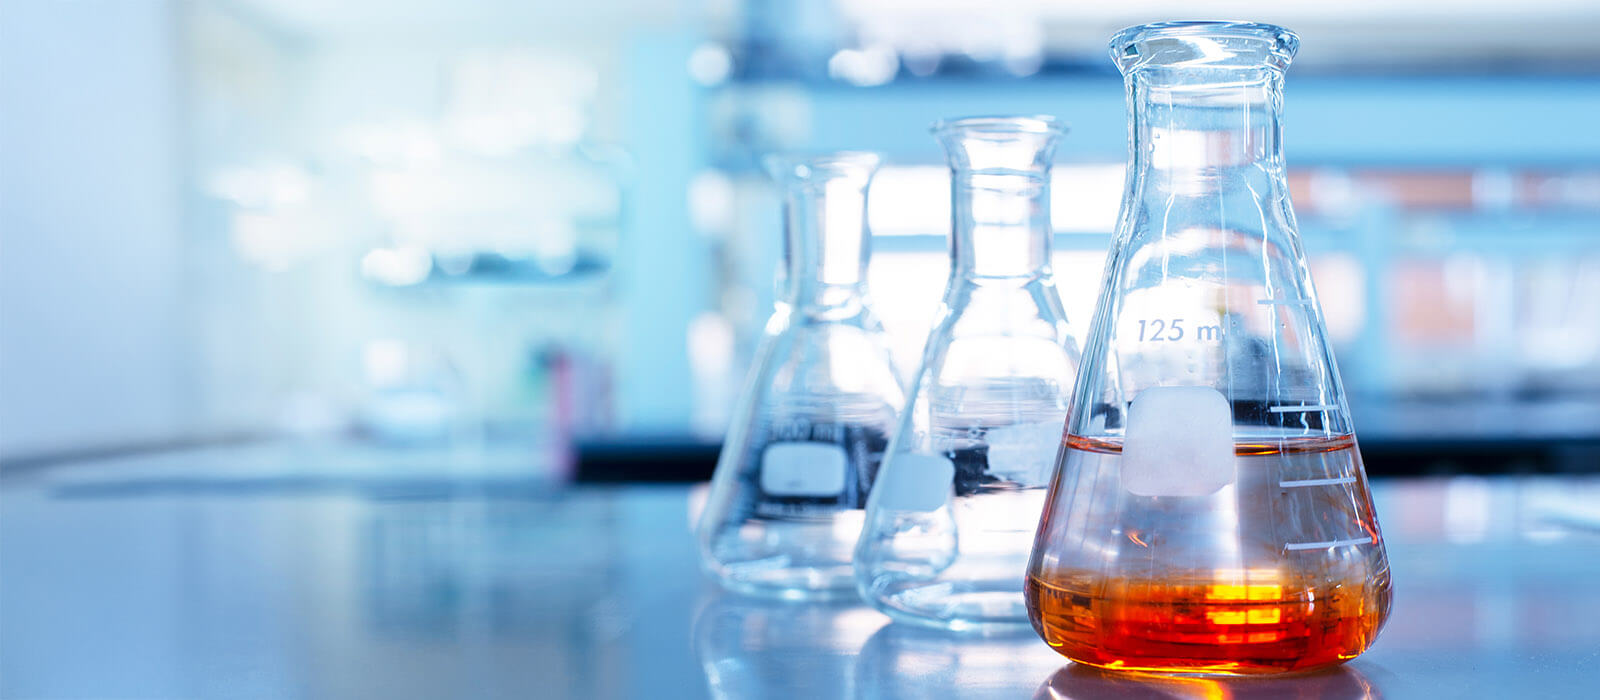

In [55]:
from IPython.display import Image
Image(filename='lab-beakers.jpeg')

--------------------------------
--------------------------------
### **Content**

- #### **pH value:**
##### PH is an important parameter in evaluating the acid–base balance of water. It is also the indicator of acidic or alkaline condition of water status. WHO has recommended maximum permissible limit of pH from 6.5 to 8.5. The current investigation ranges were 6.52–6.83 which are in the range of WHO standards.

- #### **Hardness:**
##### Hardness is mainly caused by calcium and magnesium salts. These salts are dissolved from geologic deposits through which water travels. The length of time water is in contact with hardness producing material helps determine how much hardness there is in raw water. Hardness was originally defined as the capacity of water to precipitate soap caused by Calcium and Magnesium.

- #### **Solids (Total dissolved solids - TDS):**
##### Water has the ability to dissolve a wide range of inorganic and some organic minerals or salts such as potassium, calcium, sodium, bicarbonates, chlorides, magnesium, sulfates etc. These minerals produced un-wanted taste and diluted color in appearance of water. This is the important parameter for the use of water. The water with high TDS value indicates that water is highly mineralized. Desirable limit for TDS is 500 mg/l and maximum limit is 1000 mg/l which prescribed for drinking purpose.

- #### **Chloramines:**
##### Chlorine and chloramine are the major disinfectants used in public water systems. Chloramines are most commonly formed when ammonia is added to chlorine to treat drinking water. Chlorine levels up to 4 milligrams per liter (mg/L or 4 parts per million (ppm)) are considered safe in drinking water.

- #### **Sulfate:**
##### Sulfates are naturally occurring substances that are found in minerals, soil, and rocks. They are present in ambient air, groundwater, plants, and food. The principal commercial use of sulfate is in the chemical industry. Sulfate concentration in seawater is about 2,700 milligrams per liter (mg/L). It ranges from 3 to 30 mg/L in most freshwater supplies, although much higher concentrations (1000 mg/L) are found in some geographic locations.

- #### **Conductivity:**
##### Pure water is not a good conductor of electric current rather’s a good insulator. Increase in ions concentration enhances the electrical conductivity of water. Generally, the amount of dissolved solids in water determines the electrical conductivity. Electrical conductivity (EC) actually measures the ionic process of a solution that enables it to transmit current. According to WHO standards, EC value should not exceeded 400 μS/cm.

- #### **Organic_carbon:**
##### Total Organic Carbon (TOC) in source waters comes from decaying natural organic matter (NOM) as well as synthetic sources. TOC is a measure of the total amount of carbon in organic compounds in pure water. According to US EPA < 2 mg/L as TOC in treated / drinking water, and < 4 mg/Lit in source water which is use for treatment.

- #### **Trihalomethanes:**
##### THMs are chemicals which may be found in water treated with chlorine. The concentration of THMs in drinking water varies according to the level of organic material in the water, the amount of chlorine required to treat the water, and the temperature of the water that is being treated. THM levels up to 80 ppm is considered safe in drinking water.

- #### **Turbidity:**
##### The turbidity of water depends on the quantity of solid matter present in the suspended state. It is a measure of light emitting properties of water and the test is used to indicate the quality of waste discharge with respect to colloidal matter. The mean turbidity value obtained for Wondo Genet Campus (0.98 NTU) is lower than the WHO recommended value of 5.00 NTU.

- #### **Potability:**
##### Indicates if water is safe for human consumption where 1 means Potable and 0 means Not potable.
--------------------------------

## **Import Libraries**


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score
from pickle import dump

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

---------------------------------------
---------------------------------------
## **Exploratory Data Analysis (EDA)**

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**
 -------------------------

In [57]:
df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [58]:
df.shape

(3276, 10)

In [59]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [61]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [62]:
df.duplicated().sum()

0

------------------------------
### **Data Cleaning**
-----------------------------

In [63]:
missing_cols = ['ph', 'Sulfate', 'Trihalomethanes']
for col in missing_cols:
    df[col] = df.groupby('Potability')[col].transform(lambda x: x.fillna(x.median()))


##### **Missing values ​​were compensated for using Group-wise Median Imputation based on the Potability variable, allowing for the preservation of the distinctive chemical properties of each class and minimizing the statistical distortion of the data.**

In [64]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

-----------------------------------------
### **Basic Statistical Overview**
-------------------------------------------
- Summary Statistical : **describe()**
---------------------------------------------

In [65]:
df[['ph', 'Hardness', 'Solids', 'Sulfate']].describe()

,ph,Hardness,Solids,Sulfate
count,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.074069,196.369496,22014.092526,333.544928
std,1.470043,32.879761,8768.570828,36.146829
min,0.000000,47.432000,320.942611,129.000000
25%,6.277673,176.850538,15666.690297,317.094638
50%,7.035456,196.967627,20927.833607,333.389426
75%,7.870050,216.667456,27332.762127,350.385756
max,14.000000,323.124000,61227.196008,481.030642


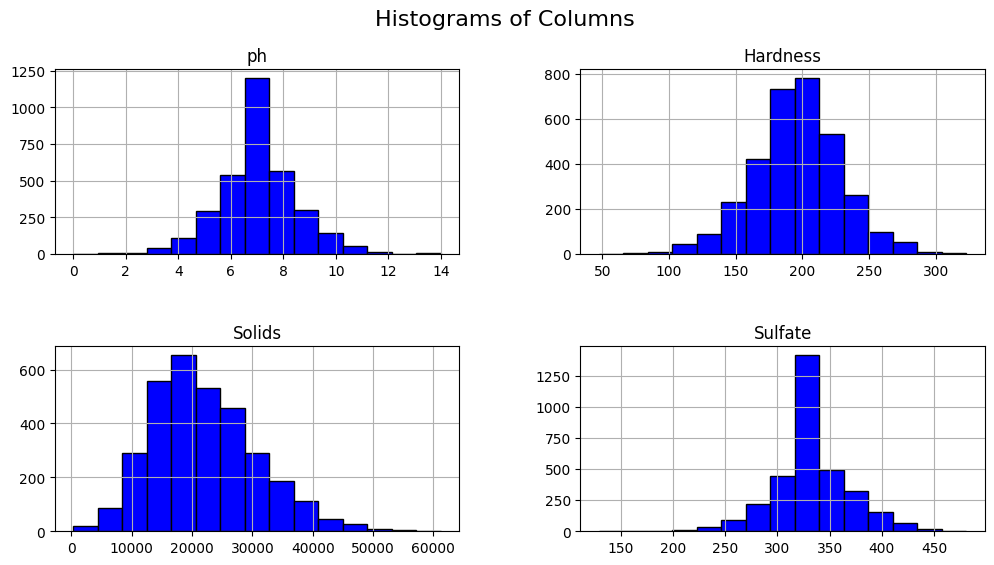

In [66]:
df[['ph', 'Hardness', 'Solids', 'Sulfate']].hist(bins=15, figsize=(12, 6), color='blue', edgecolor='black')
plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)  
plt.show()

- #### pH : Average 7.07, std 1.47. Chemically, the pH scale is logarithmic, meaning that a change from 7 to 6 represents a tenfold increase in acidity. The presence of values ​​as high as 0 and as low as 14 (maximum and minimum values) indicates that the data contains both highly acidic and highly alkaline water.
- #### Solids : The average is approximately 22,014, and the std is approximately 8,768. This is a very large deviation (representing about 40% of the average value). The range is extremely wide, starting from 320 and reaching over 61,227.
#### Summary : The data are statistically normal distributed, but chemically the ranges are very wide and cover extreme conditions (from very pure water to highly polluted or saline water). This suggests that the data were likely collected from diverse and different environmental sources.

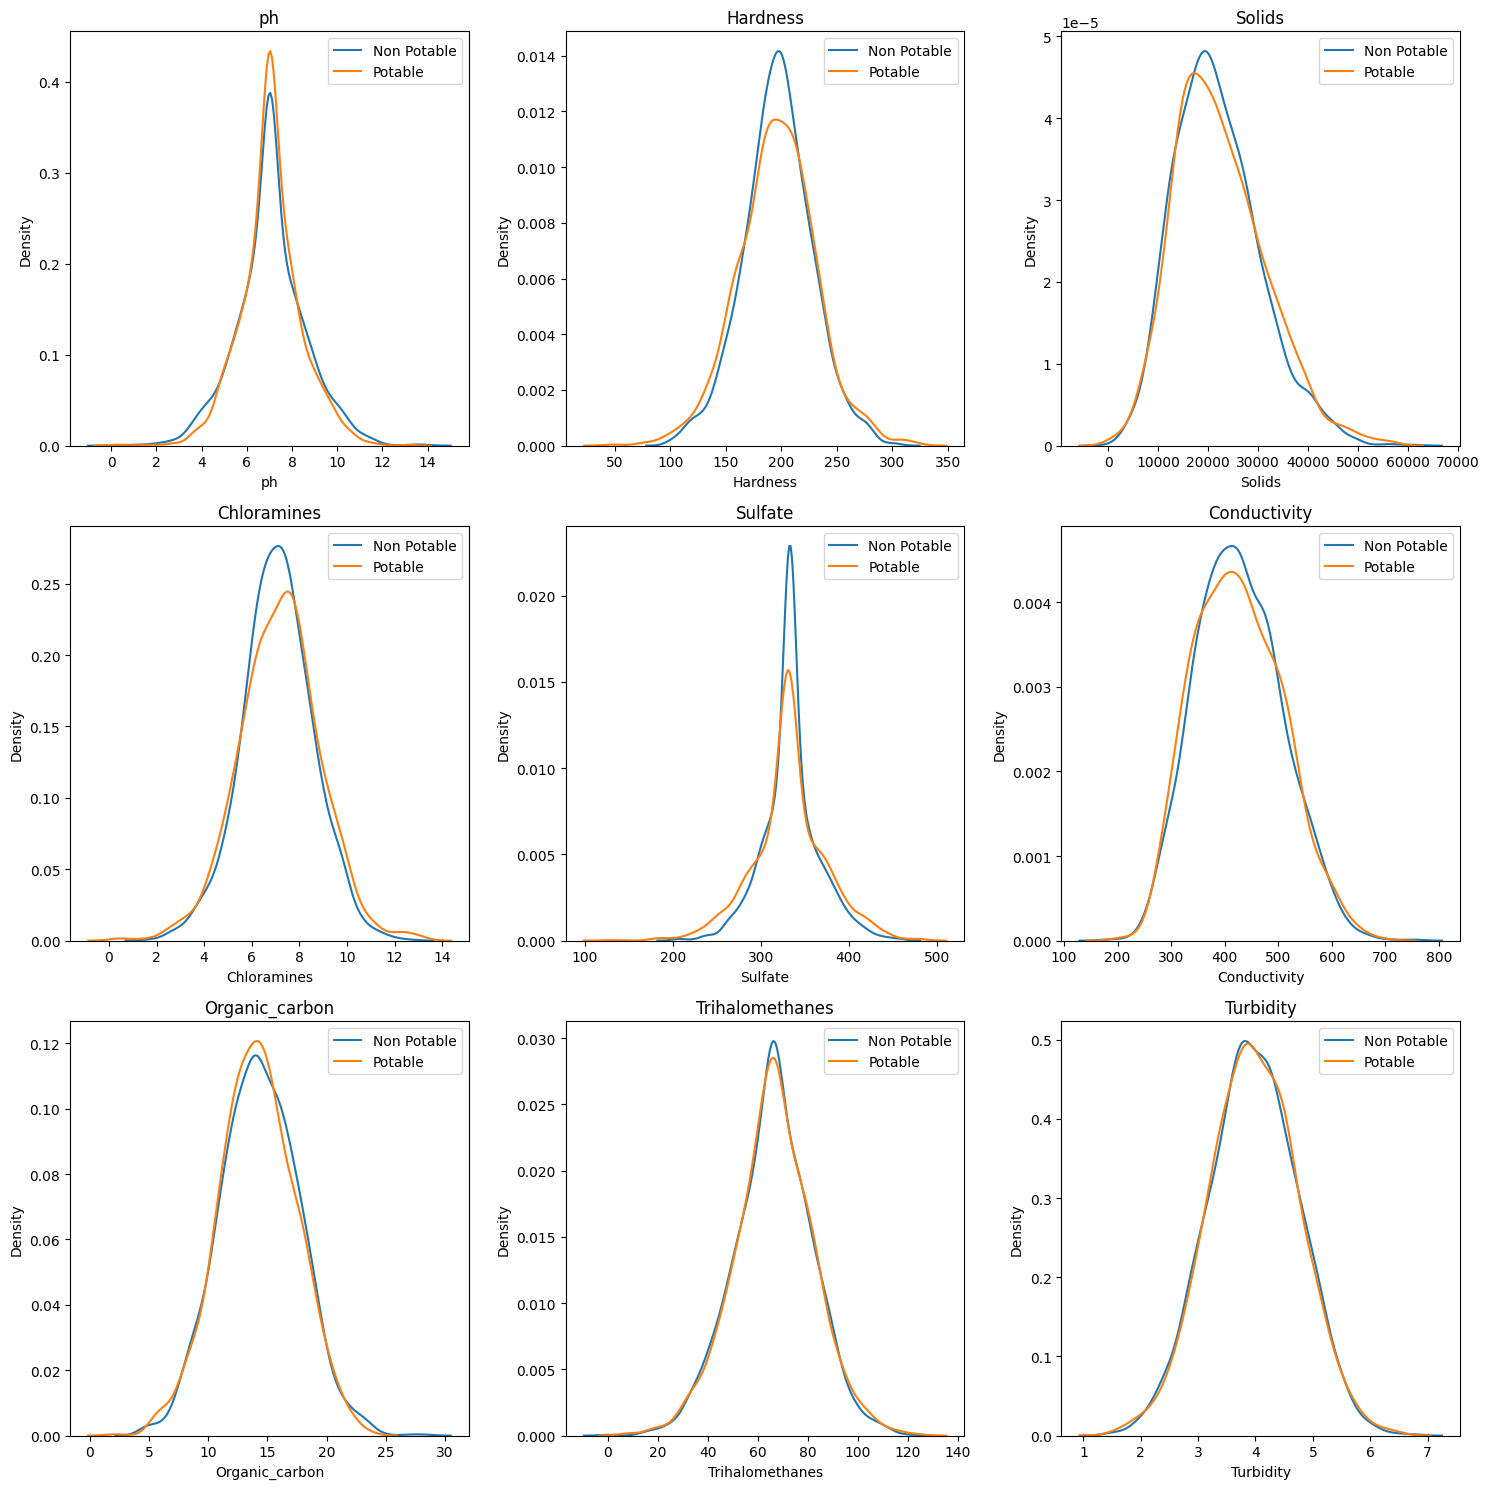

In [67]:
non_potable = df.query("Potability == 0")
potable = df.query("Potability == 1")

plt.figure(figsize = (15,15))
for ax, col in enumerate(df.columns[:9]):
    plt.subplot(3,3, ax + 1)
    plt.title(col)
    sns.kdeplot(x = non_potable[col], label = "Non Potable")
    sns.kdeplot(x = potable[col], label = "Potable")
    plt.legend()
plt.tight_layout()

---------------------------------
---------------------------------
## **Detect Outliers**
---------------------------------

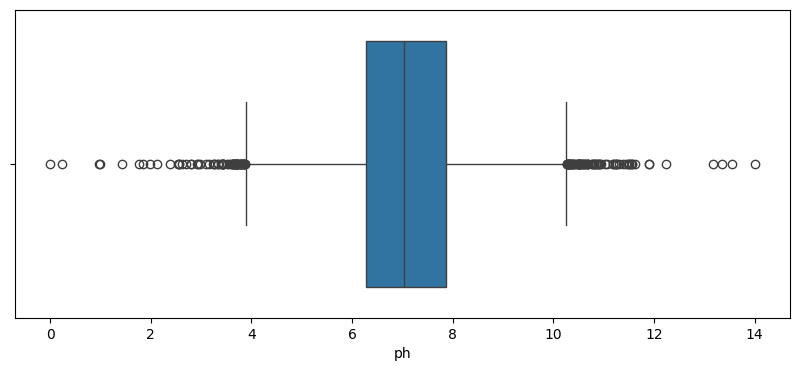

In [68]:
fig, axes = plt.subplots(nrows=1,ncols=1)
fig.set_size_inches(10, 4)
sns.boxplot(data=df,x="ph",orient="o")
plt.show()

##### **50% of the range falls almost entirely within the global standards for drinking water (6.5-8.5). This statistically means that half of the data samples have an ideal and desirable pH level for drinking.**

In [69]:
df.loc[df['ph']>=13]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
263,13.175402,47.432000,19237.949676,8.907020,375.147315,500.245952,12.083896,66.678214,4.106924,1
2075,14.000000,235.677458,24008.992040,5.635029,381.097711,460.745267,13.452538,72.859468,3.170994,0
2868,13.541240,187.606792,13475.912773,6.756055,333.389426,411.264465,15.142667,74.448559,3.529191,0
2895,13.349889,152.776455,18464.900775,6.717973,334.864070,450.846369,17.192564,85.883523,2.531075,0


In [70]:
df.loc[df['ph']<=0]

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3014,0.0,214.846144,49456.587108,7.897539,333.389426,583.448849,7.702328,77.712891,4.92884,0


In [71]:
def find_outliers(df , treshold) : 
    outliers = {}
    outliers_info = {}
    for col in df.columns : 
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - treshold * IQR
        upper_bound = Q3 + treshold * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_info[col] = {
            'Count' : outliers[col].shape[0],
            'Percantage' : 100 * outliers.shape[0] / df.shape[0], 
            'lower_bound' : lower_bound,
            'upper_bound' : upper_bound,
        } 

    return pd.DataFrame(outliers_info)

In [72]:
find_outliers(df , 2)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
Count,44.000000,17.000000,11.000000,16.000000,127.000000,1.000000,3.000000,9.000000,1.000000,0.0
Percantage,1.343101,0.518926,0.335775,0.488400,3.876679,0.030525,0.091575,0.274725,0.030525,0.0
lower_bound,3.092918,97.216701,-7665.453364,2.152488,250.512401,133.618633,3.082101,16.609748,1.318493,-2.0
upper_bound,11.054804,296.301293,50664.905788,12.089820,416.967993,713.908085,25.541352,116.704517,6.621538,3.0


In [73]:
def drop_outliers (df , columns , treshold )  :
    outliers = {}
    for col in columns : 
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1 

        lower_bound = Q1 - treshold * IQR
        upper_bound = Q3 + treshold * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)] 
    return df

In [74]:
numeric_cols = df.drop(columns = 'Potability' , axis = 1).columns

In [75]:
numeric_cols

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity'],
      dtype='object')

In [76]:
df = drop_outliers(df , numeric_cols ,2)

In [77]:
df.shape

(3059, 10)

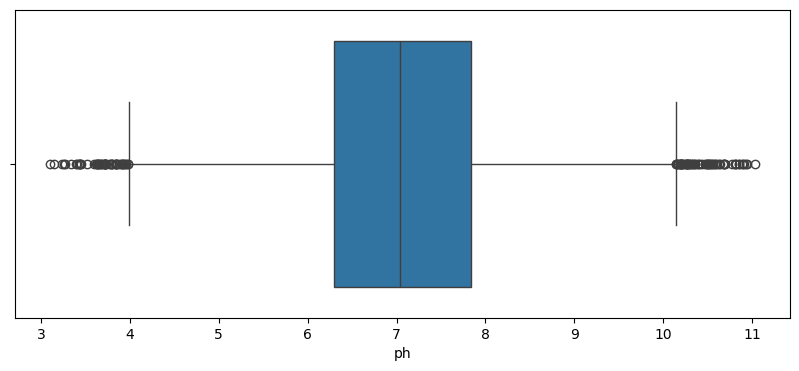

In [78]:
fig, axes = plt.subplots(nrows=1,ncols=1)
fig.set_size_inches(10, 4)
sns.boxplot(data=df,x="ph",orient="o")
plt.show()

-----------------------------
### **Checking Correlation between the features**
-----------------------------

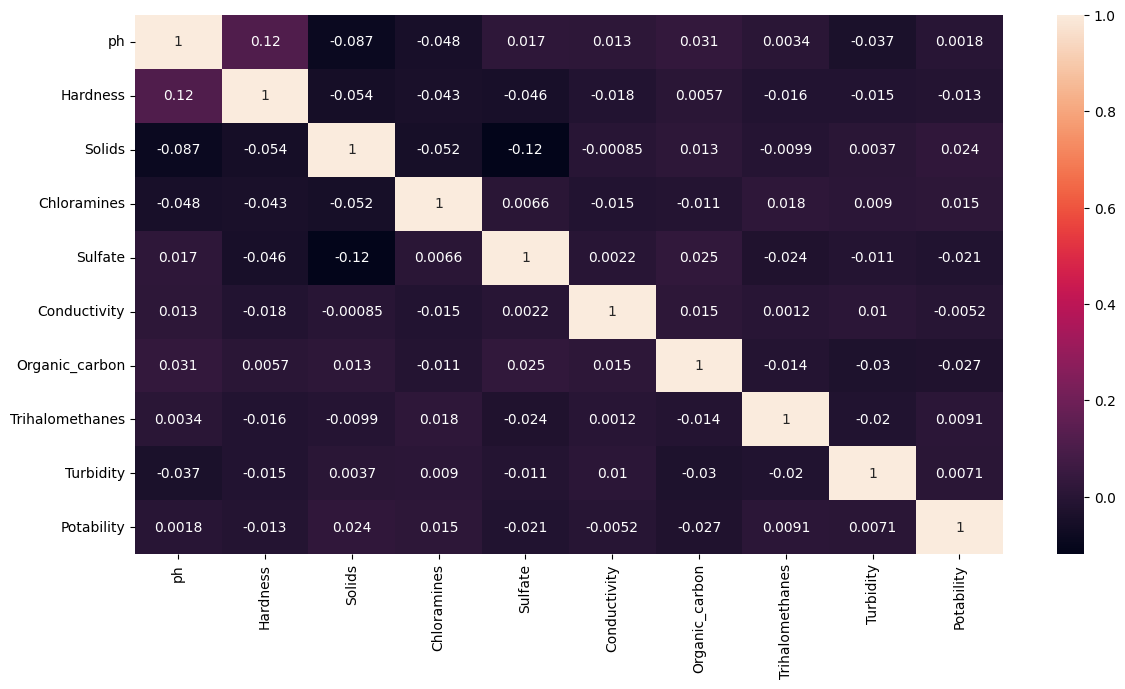

In [79]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

In [80]:
df.loc[(df['ph']>=10.5) & (df['Potability']==1),['ph','Potability']]

,ph,Potability
768,10.538098,1
805,10.905076,1
1155,10.774318,1
1227,10.550273,1
3142,10.503787,1
3246,10.667364,1
3249,10.808157,1


- #### **Although some samples classified as potable water show relatively high pH values, potability depends on the combined interaction of a range of physical and chemical properties, reflecting the multidimensional nature of water quality assessment.**

In [81]:
df.loc[
    (df['ph'] >= 10.5) & (df['Potability'] == 1),
    ['ph', 'Solids', 'Turbidity', 'Sulfate', 'Trihalomethanes']
]

,ph,Solids,Turbidity,Sulfate,Trihalomethanes
768,10.538098,13867.244196,3.823093,409.446730,72.730639
805,10.905076,16099.151896,3.720264,369.683867,80.749849
1155,10.774318,38037.353074,3.229834,350.000236,66.678214
1227,10.550273,32150.979393,3.951304,331.838167,85.393399
3142,10.503787,38605.331530,5.370458,331.838167,51.697894
3246,10.667364,28912.202201,4.135569,276.634391,55.147364
3249,10.808157,29614.348790,4.362542,304.622061,47.896406


- #### **The analysis showed that some samples were classified as potable water despite exceeding the recommended health limits for some characteristics, indicating that the Potability variable in the dataset reflects a multifactorial statistical pattern rather than a literal application of regulatory standards.**

In [82]:
def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.show()

In [83]:
df['ph_out_of_range'] = ((df['ph'] < 6.5) | (df['ph'] > 8.5)).astype(int)

In [84]:
df['ph_out_of_range']

0       0
1       1
2       0
3       0
4       1
       ..
3271    1
3272    0
3273    1
3274    1
3275    0
Name: ph_out_of_range, Length: 3059, dtype: int32

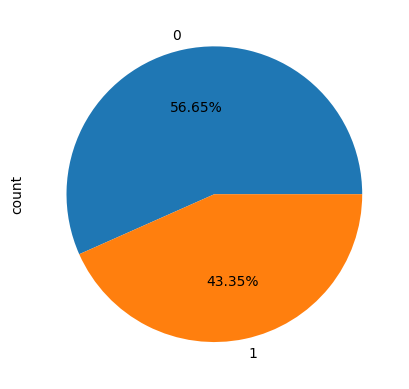

In [85]:
pie(df,'ph_out_of_range')

In [86]:
df['high_solids'] = (df['Solids'] > 1000).astype(int)

In [87]:
df['high_solids']

0       1
1       1
2       1
3       1
4       1
       ..
3271    1
3272    1
3273    1
3274    1
3275    1
Name: high_solids, Length: 3059, dtype: int32

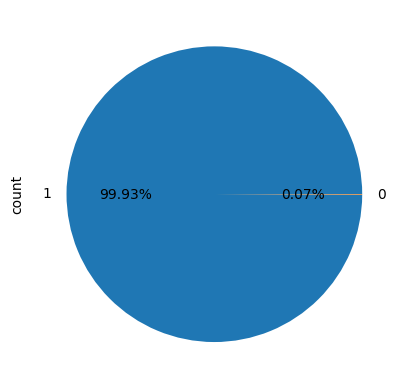

In [88]:
pie(df,'high_solids')

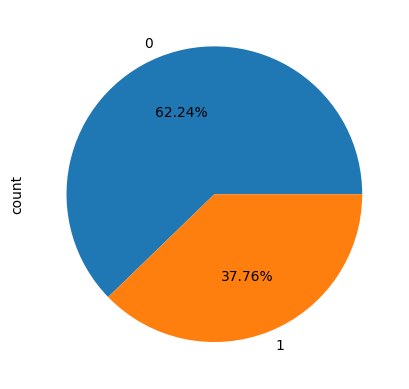

In [89]:
pie(df,'Potability')

------------------------------------
## **Observation**
------------------------------------

In [90]:
ph = round(len(df.loc[(df['ph'] <= 6.5) | (df['ph'] >=8.5)]) * 100 / df.shape[0],2)
Hardness = round(len(df.loc[df['Hardness'] > 120]) * 100 / df.shape[0],2)
Solids = round(len(df.loc[df['Solids'] > 500]) * 100 / df.shape[0],2)
Chloramines = round(len(df.loc[(df['Chloramines'] <= 0.2) | (df['Chloramines'] >5)]) * 100 / df.shape[0],2)
Organic_carbon = round(len(df.loc[(df['Organic_carbon'] >= 2)]) * 100 / df.shape[0],2)
Trihalomethanes = round(len(df.loc[(df['Trihalomethanes'] >= 80)]) * 100 / df.shape[0],2)
Turbidity = round(len(df.loc[(df['Turbidity'] >= 5)]) * 100 / df.shape[0],2)

The_percentage_of_out_of_range_values_in_each_column = ({'ph %': ph, 'Hardness %': Hardness,'Solids %': Solids, 'Chloramines %': Chloramines,
                                                         'Organic_carbon %':Organic_carbon, 'Trihalomethanes %':Trihalomethanes, 'Turbidity %': Turbidity})
The_percentage_of_out_of_range_values_in_each_column = pd.Series(The_percentage_of_out_of_range_values_in_each_column)
The_percentage_of_out_of_range_values_in_each_column

ph %                  43.35
Hardness %            98.86
Solids %              99.97
Chloramines %         91.96
Organic_carbon %     100.00
Trihalomethanes %     18.54
Turbidity %            9.28
dtype: float64

- #### **The ratio of values ​​outside the reference ranges for chemisochemical diversity was analyzed to assess drinking water quality and its compliance with approved health standards. The organic pH value was found to be significantly higher than the values ​​outside the agricultural range (6.5–8.5), indicating the presence of impurities that could affect food yields.**

- #### **In contrast, turbidity and trihalomethanes showed only slight variations from values ​​exceeding the reference limits, which is reflected in the water clarity and byproducts.**

- #### **Other values, such as hardness, total dissolved solids (TDS), and organic carbon, were relatively high compared to the values ​​outside the reference range, indicating that these values ​​do not necessarily represent specific indicators but rather reflect actual variations.**

- #### **Therefore, classifying values ​​outside the domain should be done with caution, relying on better standards such as the World Health Organization (WHO) or the US Environmental Protection Agency (EPA), in addition to the absence of discrepancies, and interpreting them accurately to avoid misleading conclusions.**

---------------------------------
---------------------------------
## **Model**
---------------------------------
### **Spliting Data to train and test**
---------------------------------

In [91]:
x=df.drop(['Potability'],axis=1)
y=df['Potability']

x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.25,random_state=1234)

In [92]:
print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_test : {x_test.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_test : {y_test.shape}')

shape of x_train : (764, 11)
shape of x_test : (2295, 11)
-------------------------------
shape of y_train : (764,)
shape of y_test : (2295,)


In [93]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [95]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)
#y_proba = xgb.predict_proba(x_test)[:, 1]
#y_pred_custom = (y_proba > 0.27).astype(int)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC_AUC:\n",roc_auc_score(y_test, y_pred))
print('confusion matrix:\n' , confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.84      0.76      1407
           1       0.62      0.43      0.50       888

    accuracy                           0.68      2295
   macro avg       0.66      0.63      0.63      2295
weighted avg       0.67      0.68      0.66      2295

ROC_AUC:
 0.630392919572024
confusion matrix:
 [[1175  232]
 [ 510  378]]


- #### **The XGBoost model demonstrated balanced performance in predicting water potability, achieving an ROC-AUC of approximately 0.73, reflecting its ability to model nonlinear relationships and complex interactions between the physical and chemical properties of water.**

--------------------------

In [ ]:
# !jupyter nbconvert --to html "water-potability-classification.ipynb"

[NbConvertApp] Converting notebook water-potability-classification.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 1167015 bytes to water-potability-classification.html
